In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from pathlib import Path

In [3]:
SCRIPT_DIR = Path.cwd()
RESULTS_DIR = SCRIPT_DIR.parent/"results"

In [4]:
ds = [9, 13, 17, 21, 25]

In [5]:
df = pd.concat(
    [pd.read_csv(RESULTS_DIR / f"summary_d{d}_chi6_bit-flip.csv").assign(d=d) for d in ds],
    ignore_index=True
)
df_sorted = df.sort_values(by = ["d", "noise"])

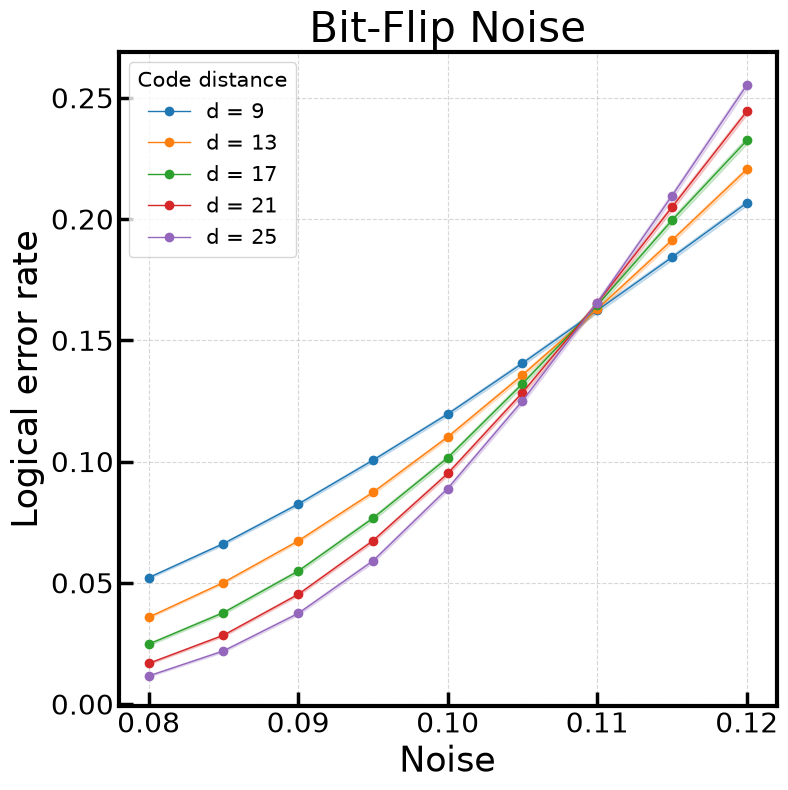

In [6]:
fig, ax = plt.subplots(figsize=(8,8))
ax.tick_params(axis='y', direction='in', labelsize= 20, size = 10,which='both',width = 2.5)

ax.tick_params(axis='x', direction='in', labelsize= 20, size = 10,which='both',width = 2.5)


for spine in ax.spines.values():
        spine.set_linewidth(3)

for d_val, sub_df in df_sorted.groupby("d"):
    line, = ax.plot(
        sub_df["noise"], 
        sub_df["error_rate"], 
        marker="o", 
        linewidth=1, 
        label=f"d = {d_val}"
    )
    ax.fill_between(
        sub_df["noise"],
        sub_df["ci_low"],
        sub_df["ci_high"],
        color=line.get_color(),
        alpha=0.2  # Transparency for confidence region
    )

plt.xlabel("Noise", size = 25)
plt.ylabel("Logical error rate", size = 25)
plt.title("Bit-Flip Noise", size = 30)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Code distance", fontsize = 15, title_fontsize = 15)
plt.tight_layout()

plt.savefig(RESULTS_DIR/"bitflip_threshold.png",
            dpi=600,                    # High resolution
            bbox_inches='tight',        # Remove extra whitespace
            pad_inches=0.05,           # Small padding
            transparent=False,         # Set to True if needed
            facecolor='white'          # White background
            )

In [7]:
ds = [9,13,17,21,25]

In [8]:
df = pd.concat(
    [pd.read_csv(RESULTS_DIR / f"summary_d{d}_chi6_depolarize.csv").assign(d=d) for d in ds],
    ignore_index=True
)
df_sorted = df.sort_values(by = ["d", "noise"])

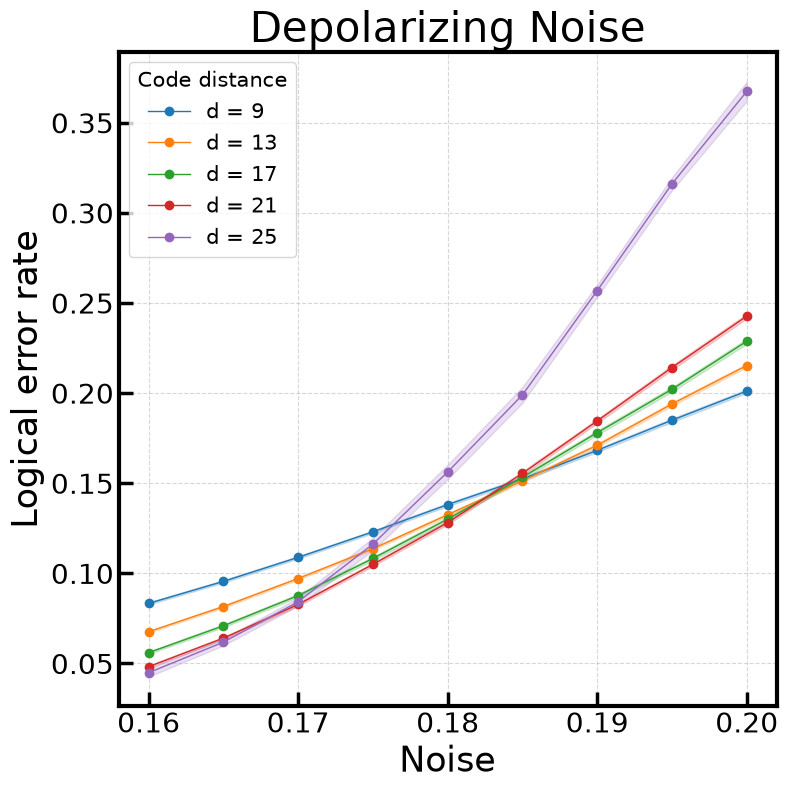

In [9]:
fig, ax = plt.subplots(figsize=(8,8))
ax.tick_params(axis='y', direction='in', labelsize= 20, size = 10,which='both',width = 2.5)

ax.tick_params(axis='x', direction='in', labelsize= 20, size = 10,which='both',width = 2.5)


for spine in ax.spines.values():
        spine.set_linewidth(3)

for d_val, sub_df in df_sorted.groupby("d"):
    line, = ax.plot(
        sub_df["noise"], 
        sub_df["error_rate"], 
        marker="o", 
        linewidth=1, 
        label=f"d = {d_val}"
    )
    ax.fill_between(
        sub_df["noise"],
        sub_df["ci_low"],
        sub_df["ci_high"],
        color=line.get_color(),
        alpha=0.2  # Transparency for confidence region
    )

plt.xlabel("Noise", size = 25)
plt.ylabel("Logical error rate", size = 25)
plt.title("Depolarizing Noise", size = 30)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Code distance", fontsize = 15, title_fontsize = 15)
plt.tight_layout()

plt.savefig(RESULTS_DIR/"depolarizing_threshold.png",
            dpi=600,                    # High resolution
            bbox_inches='tight',        # Remove extra whitespace
            pad_inches=0.05,           # Small padding
            transparent=False,         # Set to True if needed
            facecolor='white'          # White background
            )